# ==========================================
# CIFAR-10 Image Classification using ANN
# (Without CNN and Without One-Hot Encoding)
# ==========================================

## Import Libraries

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

## ==========================================
## Step 1: Load CIFAR-10 Dataset
## ==========================================


In [9]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training Images Shape :", X_train.shape)
print("Testing Images Shape  :", X_test.shape)

Training Images Shape : (50000, 32, 32, 3)
Testing Images Shape  : (10000, 32, 32, 3)


## ==========================================
## Step 2: Normalize Images
## ==========================================

In [10]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

## ==========================================
## Step 3: Build ANN Model
## ==========================================


In [11]:
model = Sequential()

# Convert 32x32x3 image into a single vector
model.add(Flatten(input_shape=(32, 32, 3)))

# Hidden Layers
model.add(Dense(256, activation="relu"))
model.add(Dense(128, activation="relu"))

# Output Layer (10 Classes)
model.add(Dense(10, activation="softmax"))


C:\Users\Abdul\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## ==========================================
## Step 4: Compile Model
## ==========================================

In [12]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## ==========================================
## Step 5: Train Model
## ==========================================


In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.3119 - loss: 1.9099 - val_accuracy: 0.3495 - val_loss: 1.8243
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3828 - loss: 1.7206 - val_accuracy: 0.4044 - val_loss: 1.6728
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4157 - loss: 1.6339 - val_accuracy: 0.4228 - val_loss: 1.6349
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4378 - loss: 1.5758 - val_accuracy: 0.4318 - val_loss: 1.6019
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4509 - loss: 1.5366 - val_accuracy: 0.4273 - val_loss: 1.6161
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4629 - loss: 1.5044 - val_accuracy: 0.4435 - val_loss: 1.5680
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4740 - loss: 1.4742 - val_accuracy: 0.4648 - val_loss: 1.5101
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4815 - loss: 1.4528 - val_accuracy: 0.

## ==========================================
## Step 6: Evaluate Model
## ==========================================


In [14]:
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy :", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4762 - loss: 1.4934

Test Accuracy : 0.47620001435279846


## ==========================================
## Step 7: Predict an Image
## ==========================================


In [15]:
predictions = model.predict(X_test)

predicted_class = np.argmax(predictions[0])

class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

actual_class = class_names[y_test[0][0]]
predicted_label = class_names[predicted_class]

print("\nActual Class    :", actual_class)
print("Predicted Class :", predicted_label)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Actual Class    : Cat
Predicted Class : Cat


## ==========================================
## Step 8: Display Prediction
## ==========================================


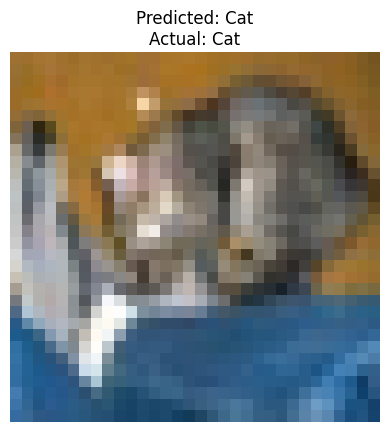

In [16]:
plt.imshow(X_test[0])
plt.title(f"Predicted: {predicted_label}\nActual: {actual_class}")
plt.axis("off")
plt.show()

# THE END 